# Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch


from sklearn.preprocessing import StandardScaler as ss

from sklearn.cluster import KMeans as kmc
from sklearn.cluster import AgglomerativeClustering as ac
from sklearn.cluster import MeanShift as msc
from sklearn.cluster import estimate_bandwidth as eb
from sklearn.cluster import DBSCAN as dbsc

# Data

In [3]:
# Load Dataset
data = pd.read_csv(r"E:\DATA FOR TEST\All Codes\Clustering\mall.csv")
df = data.copy()
print(df.head(3))

# Get X Variable
x = df.iloc[:, [3,4]].values

# Feature Scaling
x = ss().fit_transform(x)

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6


# K Means Clustring

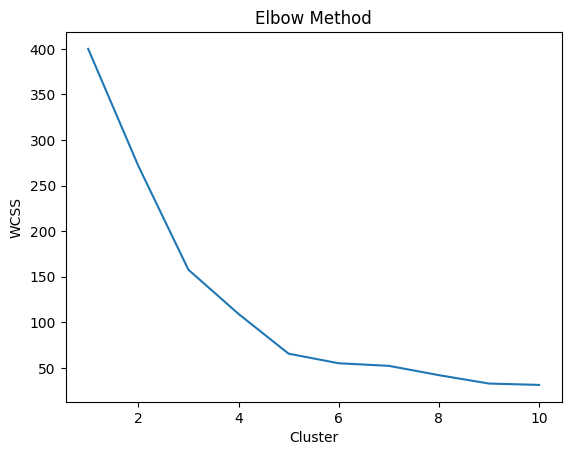

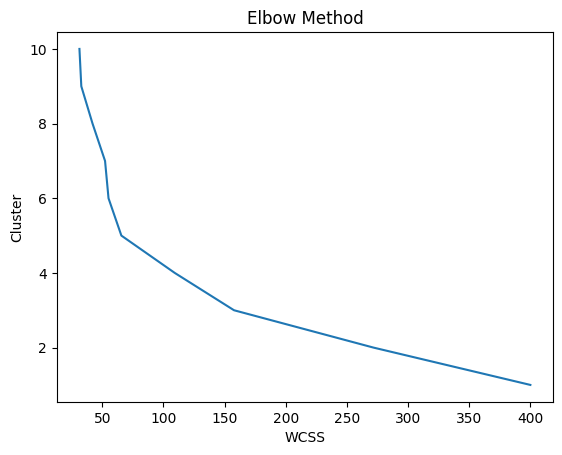

In [4]:
# Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = kmc(n_clusters = k)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Cluster')
plt.ylabel('WCSS')
plt.show()

plt.plot(wcss, range(1, 11))
plt.title('Elbow Method')
plt.ylabel('Cluster')
plt.xlabel('WCSS')
plt.show()


In [5]:
# Apply K Value To Data Set
Kmeans = kmc(n_clusters = 5, random_state = 42)
Kmeans.fit(x)
y_kmeans = Kmeans.predict(x)
# y_kmeans

# Same Best For Same Data Fit and Predict
# Apply K Value To Data Set
# Kmeans = kmc(n_clusters = 5)
# y_kmeans = Kmeans.fit_predict(x)
# y_kmeans

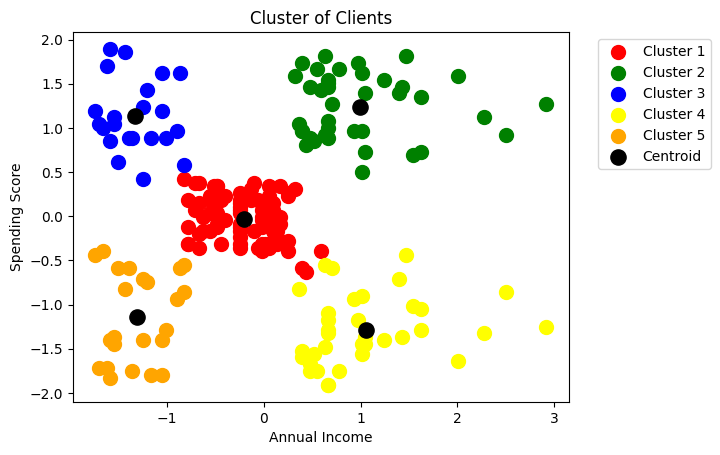

In [6]:
# Visulize The Cluster
plt.scatter(x[y_kmeans == 0,0], x[y_kmeans == 0,1], s = 100, c= 'red', label = 'Cluster 1')
plt.scatter(x[y_kmeans == 1,0], x[y_kmeans == 1,1], s = 100, c= 'green', label = 'Cluster 2')
plt.scatter(x[y_kmeans == 2,0], x[y_kmeans == 2,1], s = 100, c= 'blue', label = 'Cluster 3')
plt.scatter(x[y_kmeans == 3,0], x[y_kmeans == 3,1], s = 100, c= 'yellow', label = 'Cluster 4')
plt.scatter(x[y_kmeans == 4,0], x[y_kmeans == 4,1], s = 100, c= 'orange', label = 'Cluster 5')
plt.scatter(Kmeans.cluster_centers_[:, 0], Kmeans.cluster_centers_[:, 1], s = 120, c = 'black', label = 'Centroid')

plt.title('Cluster of Clients')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(loc='best', bbox_to_anchor=(1.3, 1))  # 👈 legend outsideplt.show()
plt.show()

# Herarcial Clustring

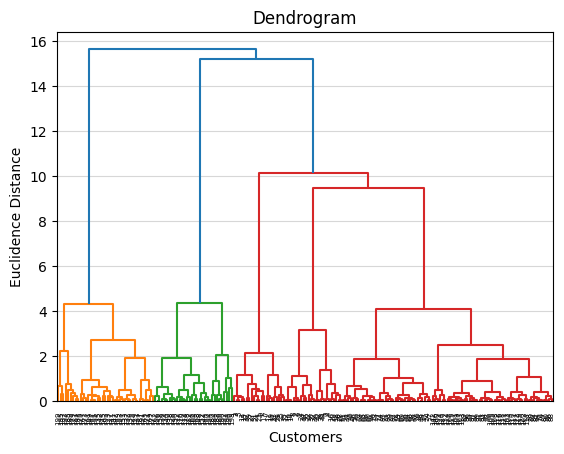

In [38]:
# Ploting the Graph by Scipy Cluster Dendrogram
Z = sch.linkage(x, method = 'ward')
dendrogram = sch.dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidence Distance')
plt.grid(axis = 'y', alpha = 0.5)
plt.show()

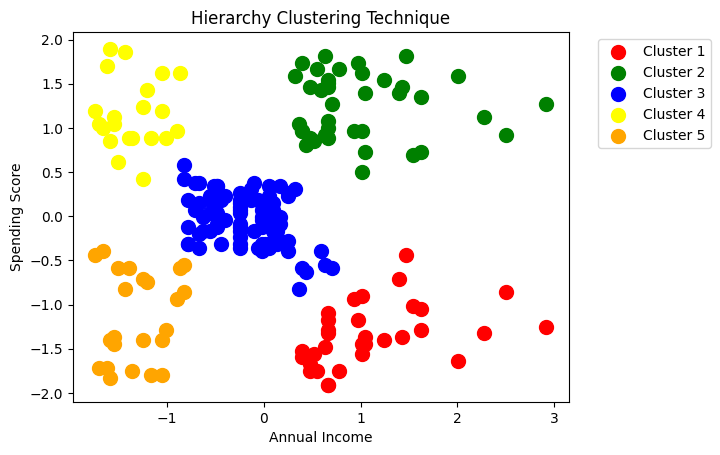

In [39]:
#  Herarchy Clusturing Agglomerative Clustering
HC = ac(n_clusters = 5, metric = 'euclidean', linkage = 'ward')
y_hc = HC.fit_predict(x)

# Visulizing Cluster
plt.scatter(x[y_hc == 0,0], x[y_hc == 0,1], s = 100, c= 'red', label = 'Cluster 1')
plt.scatter(x[y_hc == 1,0], x[y_hc == 1,1], s = 100, c= 'green', label = 'Cluster 2')
plt.scatter(x[y_hc == 2,0], x[y_hc == 2,1], s = 100, c= 'blue', label = 'Cluster 3')
plt.scatter(x[y_hc == 3,0], x[y_hc == 3,1], s = 100, c= 'yellow', label = 'Cluster 4')
plt.scatter(x[y_hc == 4,0], x[y_hc == 4,1], s = 100, c= 'orange', label = 'Cluster 5')

plt.title('Hierarchy Clustering Technique')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(loc='best', bbox_to_anchor=(1.3, 1))  # 👈 legend outsideplt.show()
plt.show()

# Mean Shifting

In [40]:
# Estimate Bandwidth
b_w = eb(x, quantile=0.2)

# Mean Shift
ms = msc(bandwidth=b_w)
ms.fit(x)

labels = ms.labels_ 
cluster_center = ms.cluster_centers_

# No of Clusters
n_clusters = len(np.unique(labels)) # Same len(set(labels))

print("Clusters:", n_clusters)

Clusters: 3


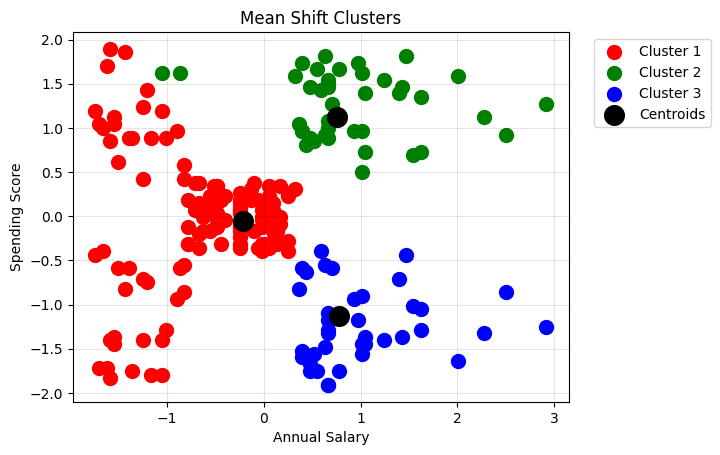

In [41]:
# Visulizing Cluster
color = ['red', 'green', 'blue', 'yellow', 'orange']

for i in range(n_clusters):
    cluster = x[labels == i]
    plt.scatter(cluster[:, 0], cluster[:, 1], 
                s=100, 
                c=color[i],   # ✅ correct
                label=f'Cluster {i+1}')

plt.scatter(cluster_center[:, 0], cluster_center[:, 1],
            s=200, c='black', marker='o', label='Centroids')

plt.title('Mean Shift Clusters')
plt.xlabel('Annual Salary')
plt.ylabel('Spending Score')
plt.legend(loc = 'best', bbox_to_anchor = (1.3, 1))
plt.grid(alpha = 0.1, color = 'black')
plt.show()



# DBSCAN Clusturing

In [51]:
dbscan = dbsc(eps = 0.5, min_samples = 5)
y_dbscan = dbscan.fit_predict(x)

n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
print("Clusters:", n_clusters)


Clusters: 2


In [7]:
# Visulize DB Scan 

unique_labels = set(y_dbscan)
colors = ['red', 'green', 'blue', 'yellow', 'orange', 'purple']

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'black'  # noise points
    
    class_member_mask = (labels == k)
    xy = x[class_member_mask]
    
    plt.scatter(xy[:, 0], xy[:, 1], s=50, c=col, label=f'Cluster {k}')

plt.legend()
plt.show()


NameError: name 'y_dbscan' is not defined

In [ ]:
dbsc = DBSC(eps = 0.5, min_sample = 4)
dbsc.fit_predict(x)